# 1. Get the Data

In [15]:
import pandas as pd


df = pd.read_csv('../../../datasets/TelcoChurn.csv')

# Preprocessing Resume

1. **Data Overview**
- Lower all the features
2. **Encoding**
3. **Scaler**
4. **Adjust the target distribution**

# Preprocessing PART I

In [16]:
df.columns = df.columns.str.lower()
print(df.columns)

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')


In [17]:
df_prepared = df.drop(columns=['customerid', 'gender', 'phoneservice', 'multiplelines'])
df_prepared.head()

,seniorcitizen,partner,dependents,tenure,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:


# OneHotEncoder
binary_cols = [
    'partner', 'dependents', 'paperlessbilling', 'onlinesecurity', 
    'onlinebackup', 'deviceprotection', 'techsupport', 
    'streamingtv', 'streamingmovies', 'churn'
]

for col in binary_cols:
    df_prepared[col] = df_prepared[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# Ordinal Encoder
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_prepared['contract'] = df_prepared['contract'].map(contract_map)

df_prepared['totalcharges'] = pd.to_numeric(df_prepared['totalcharges'], errors='coerce')

internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
df_prepared['internetservice'] = df_prepared['internetservice'].map(internet_map)

df_prepared['paymentmethod'] = df_prepared['paymentmethod'].apply(lambda x: 1 if x == 'Electronic check' else 0)

In [19]:
df_prepared.head()

,seniorcitizen,partner,dependents,tenure,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,0,1,0,1,1,0,1,0,0,0,0,0,1,1,29.85,29.85,0
1,0,0,0,34,1,1,0,1,0,0,0,1,0,0,56.95,1889.50,0
2,0,0,0,2,1,1,1,0,0,0,0,0,1,0,53.85,108.15,1
3,0,0,0,45,1,1,0,1,1,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,2,2,0,0,0,0,0,0,0,1,1,70.70,151.65,1


# Split the data

In [20]:
X = df_prepared.drop('churn', axis = 1)
y = df_prepared['churn']


print(f"The shape of X: {X.shape}")
print(f'The shape of Y: {y.shape}')

The shape of X: (7043, 16)
The shape of Y: (7043,)


In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, )
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Get the models, metrics and pipeline

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = [DecisionTreeClassifier(), RandomForestClassifier()]


params_tree = {
    'max_depth': [5, 7, 9, 10, 12],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'class_weight': ['balanced', None],
    'min_samples_split': [2, 5]
}


# Create the Pipeline


Training Model: DecisionTreeClassifier

Best Parameters found:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5}

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1294
           1       0.50      0.79      0.62       467

    accuracy                           0.74      1761
   macro avg       0.70      0.75      0.71      1761
weighted avg       0.80      0.74      0.75      1761



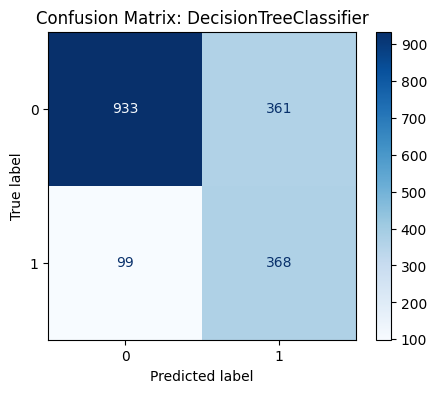


Training Model: RandomForestClassifier

Best Parameters found:
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1294
           1       0.53      0.80      0.64       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.77      1761



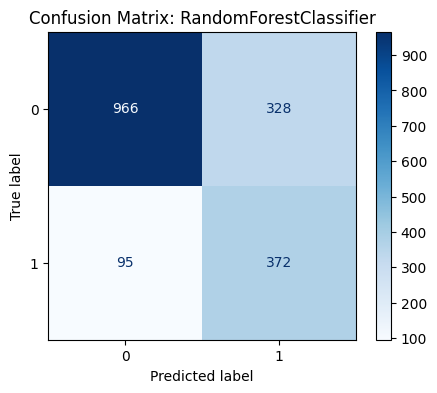

In [28]:
for model in models:
    model_name = model.__class__.__name__
    print(f'\n' + '='*50)
    print(f'Training Model: {model_name}')
    
    if model_name == "DecisionTreeClassifier":
        params = params_tree
    elif model_name == "RandomForestClassifier":
        params = params_rf
    else:
        continue

    grid = GridSearchCV(
            estimator=model, 
            param_grid=params, 
            cv=skfold, 
            scoring='recall',
            n_jobs=-1 )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    
    print(f"\nBest Parameters found:\n{grid.best_params_}")
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

In [33]:
model = grid.best_estimator_
print(f"Model choose: {model}")

Model choose: RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5)


In [36]:
import joblib

joblib.dump(model, 'model.pkl') 


['model.pkl']